Acknowledgements: Thank you to [TAISI](https://www.taisi.ca/) for providing the learning materials for this notebook.

# Concepts Vectors in Language Models

### Setup

In [1]:
import subprocess, sys


def _pip_install(*packages):
    # Bootstrap pip if it isn't present, then install the requested packages.
    subprocess.run([sys.executable, "-m", "ensurepip", "--upgrade"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)


try:
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import json
    from nnsight import LanguageModel
except ImportError:
    _pip_install("nnsight", "numpy", "matplotlib")
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import json
    from nnsight import LanguageModel

Looking in links: /var/folders/ht/879gb0f17j9__nx8w63714yw0000gn/T/tmppkscv1e1


In [2]:
print("Loading GPT-2...")
model = LanguageModel("gpt2", device_map="auto")
print(f"Done. {sum(p.numel() for p in model.parameters()):,} parameters.")

Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Done. 124,439,808 parameters.


In [3]:
DEBUG = False  # set True to skip answer requirements
ANSWER = ""

TRAIN_IDX = [0, 1, 3, 4, 5, 7, 9]
TEST_IDX  = [2, 6, 8]


def require_answer():
    err_msg = 'Please provide an answer to the question above, look for "❓"'
    if not DEBUG:
        assert ANSWER, err_msg


PAIRS = []

# DO NOT USE THESE
DEBUG_PAIRS = [
    (
        "Before starting the procedure, Dr. Chen reviewed the patient's chart, "
        "confirmed the allergy list with the nurse, and ran through the instrument count.",
        "Dr. Chen checked the basics and moved straight to the incision.",
    ),
    (
        "Amir ran the full test suite, reviewed the diff once more, and confirmed "
        "the database migration was reversible before merging the pull request.",
        "Amir pushed the change and moved on to the next ticket.",
    ),
    (
        "Before publishing, Priya replicated the key finding in a second dataset "
        "and had a colleague audit the statistical analysis.",
        "Priya submitted the paper after confirming the main result held on her original dataset.",
    ),
    (
        "Captain Torres completed every item on the pre-flight checklist, "
        "including a manual walk-around of the landing gear.",
        "Captain Torres cleared the pre-flight check from memory and prepared for departure.",
    ),
    (
        "The pharmacist called the prescribing doctor to verify the dosage "
        "before filling the prescription for the elderly patient.",
        "The pharmacist filled the prescription and moved to the next customer.",
    ),
    (
        "Before signing off, Liu ran the load calculations a second time "
        "and had a junior engineer independently verify the results.",
        "Liu signed off on the drawings after reviewing the summary page.",
    ),
    (
        "Inspector Diallo collected samples from three separate storage units, logged the temperatures, "
        "and cross-checked the paperwork before certifying the shipment.",
        "Inspector Diallo walked through the facility and certified the shipment at the end of the visit.",
    ),
    (
        "Before energising the circuit, the electrician locked out the breaker panel, "
        "tested for residual voltage at both ends, and verified continuity on the ground wire.",
        "The electrician finished the wiring and switched on the breaker.",
    ),
    (
        "Before administering the medication, Yuki confirmed the patient's wristband, "
        "checked the five rights, and verified the infusion rate matched the order.",
        "Yuki hung the bag and set the pump running.",
    ),
    (
        "Before sending the report, Marcus re-ran the query with an alternative date filter "
        "as a sanity check and reconciled the totals against the previous quarter.",
        "Marcus exported the data and attached it to the email.",
    ),
]

def validate_pairs():
    assert isinstance(PAIRS, list), "Please keep the original structure of the PAIRS variable"
    assert len(PAIRS) == 10, "Write your own 10 training pairs! The more diverse, the better."
    placeholders = ("ADD A POSITIVE EXAMPLE HERE", "ADD A NEGATIVE EXAMPLE HERE")
    for pair in PAIRS:
        assert isinstance(pair, tuple)
        assert len(pair) == 2
        assert isinstance(pair[0], str)
        assert isinstance(pair[1], str)
        assert pair[0]
        assert pair[1]
        assert pair[0] not in placeholders
        assert pair[1] not in placeholders


def plot_separation(rows, title: str, threshold=None):
    fig, axes = plt.subplots(len(rows), 1, figsize=(10, 2.2 * len(rows)), squeeze=False)
    for ax, (label, pos_p, neg_p) in zip(axes[:, 0], rows):
        ax.scatter(pos_p, [0] * len(pos_p), c="steelblue", s=140, label="Careful", zorder=3, alpha=0.85)
        ax.scatter(neg_p, [0] * len(neg_p), c="tomato", s=140, marker="x", lw=2.5, label="Corner-cutting", zorder=3)
        ax.axvline(0, c="gray", ls="--", alpha=0.4)
        if threshold is not None:
            ax.axvline(threshold, c="seagreen", ls="-", lw=2,
                       label=f"threshold = {threshold:.3f}", alpha=0.9, zorder=4)
        ax.set_yticks([])
        ax.set_xlabel("Projection value")
        ax.set_title(label)
        ax.legend(loc="upper right", fontsize=9)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_norm_diagnostics(act_norms_pos, act_norms_neg, dir_norms):
    xs = list(range(len(act_norms_pos)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.scatter(xs, act_norms_pos, c="steelblue", s=100, label="Careful (pos)", zorder=3)
    ax.scatter(xs, act_norms_neg, c="tomato", s=100, marker="x", lw=2.5,
               label="Corner-cutting (neg)", zorder=3)
    for i in xs:
        ax.plot([i, i], [act_norms_pos[i], act_norms_neg[i]], c="gray", lw=0.8, zorder=2)
    ax.set_xlabel("Training pair index")
    ax.set_ylabel("L2 norm")
    ax.set_title("Activation norms per pair")
    ax.set_xticks(xs)
    ax.legend()

    ax = axes[1]
    ax.bar(xs, dir_norms, color="mediumpurple", alpha=0.85)
    ax.set_xlabel("Training pair index")
    ax.set_ylabel("L2 norm  (‖pos - neg‖)")
    ax.set_title("Per-pair direction norms")
    ax.set_xticks(xs)

    fig.suptitle("Norm diagnostics — training activations", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_cosine_heatmap(cos_sim, n_pos):
    n_total = cos_sim.shape[0]
    n_neg = n_total - n_pos
    tick_labels = [f"pos {i}" for i in range(n_pos)] + [f"neg {i}" for i in range(n_neg)]

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cos_sim, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(n_total))
    ax.set_yticks(range(n_total))
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(tick_labels, fontsize=8)
    ax.axhline(n_pos - 0.5, c="k", lw=1.5)
    ax.axvline(n_pos - 0.5, c="k", lw=1.5)
    ax.set_title("Pairwise cosine similarity — training activations")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_direction_heatmap(dir_cos_sim):
    n = dir_cos_sim.shape[0]
    tick_labels = [f"pair {i}" for i in range(n)]

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(dir_cos_sim, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(tick_labels, fontsize=9)
    ax.set_title("Pairwise cosine similarity — per-pair direction vectors (pos - neg)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_pca(pos_acts, neg_acts):
    # 2-component PCA via SVD (no extra deps)
    acts = torch.stack(list(pos_acts) + list(neg_acts))
    centered = acts - acts.mean(0, keepdim=True)
    _, _, Vh = torch.linalg.svd(centered, full_matrices=False)
    coords = (centered @ Vh[:2].T).numpy()

    n = len(pos_acts)
    plt.figure(figsize=(6, 5))
    plt.scatter(coords[:n, 0], coords[:n, 1], c="steelblue", s=120,
                label="Careful (pos)", zorder=3, alpha=0.85)
    plt.scatter(coords[n:, 0], coords[n:, 1], c="tomato", s=120, marker="x", lw=2.5,
                label="Corner-cutting (neg)", zorder=3)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title("2-component PCA of training activations")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_adversarial(projs, true_labels, threshold):
    fig, ax = plt.subplots(figsize=(10, 2.5))
    for proj, true in zip(projs, true_labels):
        predicted = proj > threshold
        color = "steelblue" if true else "tomato"
        correct = true == predicted
        ax.scatter(proj, 0, c=color, s=180, zorder=3, alpha=0.85,
                   edgecolors="black" if not correct else color, linewidths=2.5)
    ax.axvline(threshold, c="seagreen", ls="-", lw=2,
               label=f"threshold = {threshold:.3f}", zorder=4)
    ax.axvline(0, c="gray", ls="--", alpha=0.4)
    ax.set_yticks([])
    ax.set_xlabel("Projection value")
    ax.set_title(
        "Adversarial examples  "
        "(blue = careful, red = corner-cutting; black outline = misclassified)"
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def project(a,b):
    raise NotImplementedError


OTHER_GROUPS = []
YOUR_THRESHOLD = None
direction = None
test_pos = None
test_neg = None


def plot_group_comparisson():
    valid_groups = [g for g in OTHER_GROUPS if g["direction"]]

    assert valid_groups, "Paste at least one other group's direction above first."

    d = direction.shape[0]
    for g in valid_groups:
        other_dir = torch.tensor(g["direction"])
        cosine = torch.dot(direction, other_dir).item()
        thr_str = str(g["threshold"]) if g["threshold"] is not None else "not set"
        print(f"\n{g['name']}:  cosine = {cosine:.4f}  "
            f"(random baseline ~{1 / d**0.5:.4f})  threshold = {thr_str}")
        plot_separation(
            [
                ("Your direction  —  your test examples",
                project(test_pos, direction), project(test_neg, direction)),
                (f"{g['name']}'s direction  —  your test examples",
                project(test_pos, other_dir), project(test_neg, other_dir)),
            ],
            title=f"Does {g['name']}'s direction find the same concept in your examples?",
            threshold=YOUR_THRESHOLD,
        )

### Contrastive Pairs

In [4]:
PAIRS = [
    # 1. Domain: Software Engineering
    (
        "Lin staged the code in a sandbox environment, ran the regression tests, and monitored the server logs for five minutes.",
        "Lin pushed the code straight to the live environment, bypassed the tests, and switched tabs to watch a video."
    ),
    
    # 2. Domain: Fine Dining/Culinary
    (
        "Chef Mateo tasted the broth with a clean spoon, adjusted the salt by a pinch, and tasted it once more before plating.",
        "Chef Mateo poured salt into the broth straight from the box, stirred it twice, and signaled for the waiter to serve it."
    ),
    
    # 3. Domain: Art Restoration
    (
        "Elara dabbed the canvas with a microscopic swab of solvent, paused to observe the pigment reaction, and gently dabbed again.",
        "Elara wiped the canvas with a saturated sponge of solvent, applied continuous pressure, and scrubbed the entire surface."
    ),
    
    # 4. Domain: Aircraft Maintenance
    (
        "Marcus torqued every bolt on the landing gear to exactly eighty foot-pounds and marked each one with a paint pen.",
        "Marcus hand-tightened the bolts on the landing gear until they felt snug and wiped his grease-stained hands on his overalls."
    ),
    
    # 5. Domain: Space Exploration
    (
        "Commander Vance cycled the airlock valves one by one, waiting for the green indicator light on each panel to illuminate.",
        "Commander Vance hit the manual override for the airlock valves, ignoring the flashing amber lights on the main panel."
    ),
    
    # 6. Domain: Wilderness Survival
    (
        "Chloe gathered dry tinder, arranged the kindling in a teepee structure, and struck her flint until a steady flame caught.",
        "Chloe threw wet logs onto a pile of crumpled newspaper, poured lighter fluid over the top, and tossed in a match."
    ),
    
    # 7. Domain: Financial Auditing
    (
        "Arthur cross-referenced the quarterly expense receipts against the bank statements, highlighting discrepancies in a yellow ledger.",
        "Arthur skimmed the quarterly expense totals on the summary page, assumed they aligned with the budget, and signed the ledger."
    ),
    
    # 8. Domain: SCUBA Diving
    (
        "Sam inflated his buoyancy compensator, breathed three times from his primary regulator, and examined his pressure gauge.",
        "Sam threw his buoyancy compensator over his shoulder, grabbed his mask from the deck, and jumped into the water."
    ),
    
    # 9. Domain: Film Production
    (
        "Jada secured the overhead light with two steel safety cables and taped the power cords flat against the studio floor.",
        "Jada hung the overhead light using a single plastic zip-tie and left the power cords tangled across the studio floor."
    ),
    
    # 10. Domain: Tailoring
    (
        "Mr. Rossi pinned the hemline at one-inch intervals, ironed the fold flat, and stitched along the chalk line.",
        "Mr. Rossi folded the hemline by eye as he fed the fabric into the machine, stitching straight over the raw edge."
    )
]

validate_pairs()

In [5]:
train_pairs = [PAIRS[i] for i in TRAIN_IDX]
test_pairs  = [PAIRS[i] for i in TEST_IDX]

### Extracting Activations

In [6]:
LAYER = 8
TEMPLATE = "Story:\n{story}\n\nConclusion:"

def extract_activation(story: str) -> torch.Tensor:
    text = TEMPLATE.format(story=story)
    with model.trace(text):
        h = model.transformer.h[LAYER].output[0, -1, :].save()

    return h.detach().cpu().float()


def extract_pairs(pairs: list[tuple[str, str]]) -> tuple[list[torch.Tensor], list[torch.Tensor]]:
    pos_acts, neg_acts = [], []
    for i, (pos, neg) in enumerate(pairs):
        print(f"  pair {i + 1}/{len(pairs)}", end="\r")
        pos_acts.append(extract_activation(pos))
        neg_acts.append(extract_activation(neg))
    print()
    return pos_acts, neg_acts

In [7]:
print("Extracting training activations...")
train_pos, train_neg = extract_pairs(train_pairs)
print("Extracting test activations...")
test_pos, test_neg = extract_pairs(test_pairs)

Extracting training activations...


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

  pair 7/7
Extracting test activations...
  pair 3/3


### Visualizing Activations

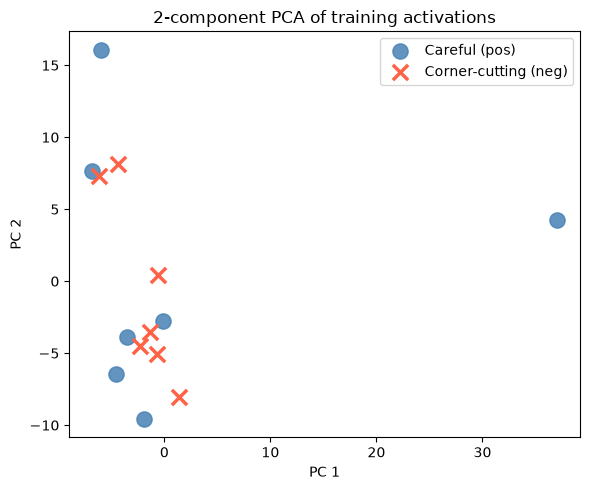

In [8]:
plot_pca(train_pos, train_neg)

In [10]:
# Activation and direction norms
act_norms_pos = torch.stack(train_pos).norm(dim=1).numpy()
act_norms_neg = torch.stack(train_neg).norm(dim=1).numpy()

per_pair_dirs = []
for i in range(len(train_pos)):
    per_pair_dirs.append(train_pos[i] - train_neg[i])

per_pair_dirs = torch.stack(per_pair_dirs)
dir_norms = per_pair_dirs.norm(dim=1).numpy()

### Activation Cosine Similarity

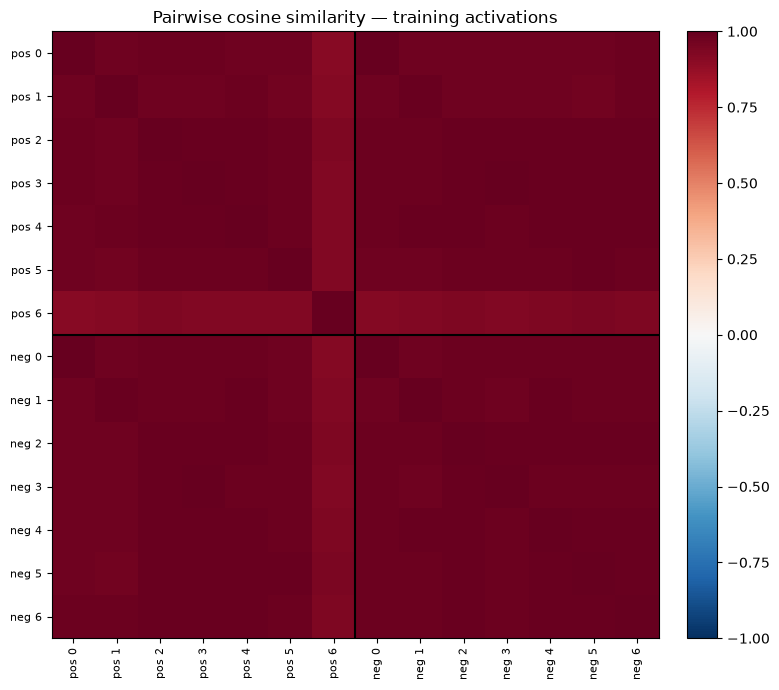

In [14]:
# Pairwise cosine similarities — raw activations
all_acts = torch.stack(train_pos + train_neg)
all_acts_normed = all_acts / all_acts.norm(dim=1, keepdim=True)
cos_sim = (all_acts_normed @ all_acts_normed.T).numpy()
plot_cosine_heatmap(cos_sim, n_pos=len(train_pos))

### Direction Cosine Similarity

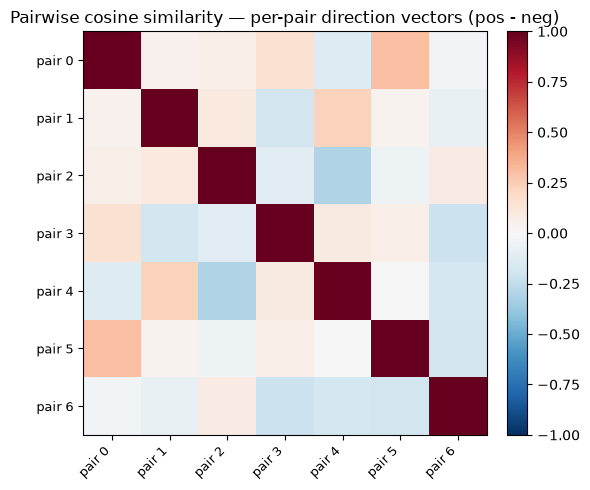

In [15]:
dirs_normed = per_pair_dirs / per_pair_dirs.norm(dim=1, keepdim=True)
dir_cos_sim = (dirs_normed @ dirs_normed.T).numpy()
plot_direction_heatmap(dir_cos_sim)


### Using Direction to Seperate The Samples

In [16]:
def concept_direction(pos_acts: list[torch.Tensor], neg_acts: list[torch.Tensor]) -> torch.Tensor:
    diff = torch.stack(pos_acts).mean(0) - torch.stack(neg_acts).mean(0)
    return diff / diff.norm()

In [18]:
direction = concept_direction(train_pos, train_neg)
print(f"Direction computed. Shape: {direction.shape}  Norm: {direction.norm():.4f}")

Direction computed. Shape: torch.Size([768])  Norm: 1.0000


In [19]:
def project(acts: list[torch.Tensor], direction: torch.Tensor) -> list[float]:
    result = []
    for a in acts:
        result.append(torch.dot(a, direction).item())

    return result

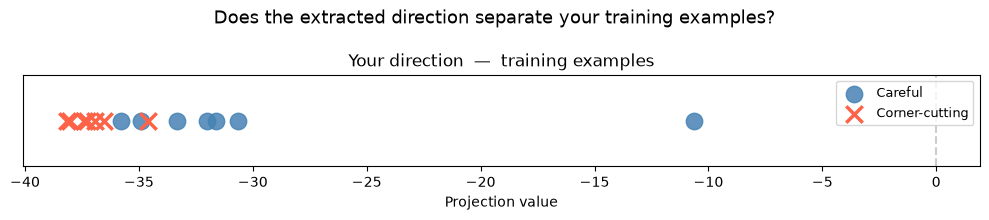

In [20]:
plot_separation(
    [
        ("Your direction  —  training examples",
         project(train_pos, direction), project(train_neg, direction)),
    ],
    title="Does the extracted direction separate your training examples?",
)


### Classification Threshold

In [36]:
YOUR_THRESHOLD = -20

# Evaluate threshold classifier on training data
train_pos_proj = project(train_pos, direction)
train_neg_proj = project(train_neg, direction)
train_correct = (
    sum(1 for p in train_pos_proj if p > YOUR_THRESHOLD)
    + sum(1 for p in train_neg_proj if p <= YOUR_THRESHOLD)
)
train_total = len(train_pos) + len(train_neg)

# Evaluate on test data
test_pos_proj = project(test_pos, direction)
test_neg_proj = project(test_neg, direction)
test_correct = (
    sum(1 for p in test_pos_proj if p > YOUR_THRESHOLD)
    + sum(1 for p in test_neg_proj if p <= YOUR_THRESHOLD)
)
test_total = len(test_pos) + len(test_neg)

print(f'Threshold: {YOUR_THRESHOLD}')
print(f'Training accuracy: {train_correct}/{train_total}')
print(f'Test accuracy:     {test_correct}/{test_total}')


Threshold: -20
Training accuracy: 8/14
Test accuracy:     3/6


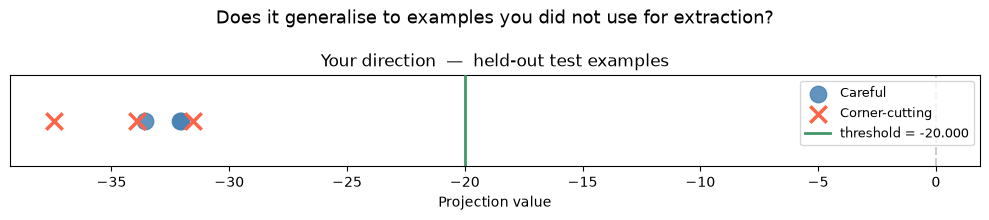

In [37]:
plot_separation(
    [
        ("Your direction  —  held-out test examples",
         project(test_pos, direction), project(test_neg, direction)),
    ],
    title="Does it generalise to examples you did not use for extraction?",
    threshold=YOUR_THRESHOLD,
)


### Cross-Group Comparision

In [38]:
# Share this output with another group
print(json.dumps(direction.tolist()))

[0.018524078652262688, 0.030231695622205734, -0.02286659926176071, 0.003628465812653303, -0.04960129037499428, -0.0291445329785347, -0.02045178972184658, 0.04459932819008827, 0.02173924818634987, -0.0030246758833527565, 0.021370526403188705, 0.08797712624073029, -0.026786446571350098, 0.006698462180793285, 0.016295768320560455, -0.024589719250798225, 0.00567940529435873, -0.04437020421028137, -0.02123391255736351, 0.021089734509587288, -0.006679747253656387, 0.07310839742422104, 0.023304414004087448, -0.019806431606411934, 0.011166869662702084, 0.043774768710136414, 0.017907632514834404, -0.0010559859219938517, -0.012915844097733498, 0.03182589262723923, 0.00600989768281579, 0.06887919455766678, -0.028478890657424927, 0.06147400662302971, -0.11058291047811508, -0.05182725191116333, -0.060356076806783676, -0.07440927624702454, 0.008938083425164223, -0.0056794555857777596, 0.003984355367720127, -0.05644639953970909, -0.0435878187417984, 0.029592690989375114, -0.05624822899699211, 0.00567

In [43]:
OTHER_GROUPS = [
    {"name": "Group 2",  "direction": [0.018524078652262688, 0.030231695622205734, -0.02286659926176071, 0.003628465812653303, -0.04960129037499428, -0.0291445329785347, -0.02045178972184658, 0.04459932819008827, 0.02173924818634987, -0.0030246758833527565, 0.021370526403188705, 0.08797712624073029, -0.026786446571350098, 0.006698462180793285, 0.016295768320560455, -0.024589719250798225, 0.00567940529435873, -0.04437020421028137, -0.02123391255736351, 0.021089734509587288, -0.006679747253656387, 0.07310839742422104, 0.023304414004087448, -0.019806431606411934, 0.011166869662702084, 0.043774768710136414, 0.017907632514834404, -0.0010559859219938517, -0.012915844097733498, 0.03182589262723923, 0.00600989768281579, 0.06887919455766678, -0.028478890657424927, 0.06147400662302971, -0.11058291047811508, -0.05182725191116333, -0.060356076806783676, -0.07440927624702454, 0.008938083425164223, -0.0056794555857777596, 0.003984355367720127, -0.05644639953970909, -0.0435878187417984, 0.029592690989375114, -0.05624822899699211, 0.005673495586961508, 0.024565748870372772, 0.024718714877963066, -0.013367624953389168, -0.0609147734940052, 0.01913090981543064, -0.011814026162028313, -0.08259513974189758, -0.025342248380184174, -0.004861572291702032, 0.03982355073094368, -0.005619879812002182, 0.027053842321038246, 0.00949596893042326, -0.01275336928665638, 0.006037544459104538, -0.0441901795566082, -0.0027592561673372984, 0.012744945473968983, 0.0037639657966792583, 0.0072037167847156525, 0.04032991826534271, 0.014426281675696373, -0.006538049317896366, 0.03044685162603855, -0.02229110524058342, 0.007015598472207785, -0.00017851858865469694, -0.010439831763505936, 0.005958410445600748, 0.009494423866271973, -0.06430089473724365, -0.020986685529351234, 0.011576646007597446, 0.018147075548768044, -0.07092966139316559, -0.020161481574177742, 0.010971248149871826, 0.022352371364831924, -0.06771575659513474, -0.0024755869526416063, -0.03872188925743103, -0.0036332113668322563, 0.02380462735891342, 0.0013349243672564626, -0.023372028023004532, -0.0014565967721864581, -0.0005786286201328039, 0.060433175414800644, 0.02248469367623329, 0.08717016130685806, 0.0012481859885156155, 0.03011905588209629, -0.012372592464089394, -0.027830567210912704, 0.08091553300619125, -0.05665479227900505, -0.021232644096016884, 0.0009023427846841514, 0.05388043075799942, 0.05310623347759247, 0.004885245580226183, -0.02870079129934311, -0.049247391521930695, -0.022873301059007645, 0.013391982764005661, -0.019954565912485123, 0.0270607341080904, 0.06398329138755798, -0.021771186962723732, -0.002675524912774563, -0.0017846516566351056, -0.02694399654865265, 0.027205612510442734, -0.04608617722988129, 0.011528347618877888, -0.00431816978380084, -0.015703901648521423, 0.027776043862104416, 0.03498036041855812, -0.002846699906513095, -0.010319619439542294, 0.024205170571804047, -0.009017884731292725, -0.017771506682038307, 0.003147606737911701, -0.029276831075549126, -0.019480746239423752, 0.017091205343604088, -0.019223345443606377, -0.04726603999733925, 0.025726839900016785, 0.015951737761497498, -0.018124006688594818, 0.005965522490441799, 0.03074793703854084, -0.0043182033114135265, 0.003931449260562658, 0.026002343744039536, 0.00912567600607872, 0.04356858506798744, 0.04697154089808464, 0.006262566894292831, -0.026525896042585373, 0.03393813222646713, 0.03228006139397621, 0.03687658533453941, -0.06634584069252014, -0.02212194725871086, -0.006774497218430042, -0.05683271214365959, 0.004302676767110825, -0.0671306699514389, -0.013143128715455532, -0.038683321326971054, 0.03361460193991661, 0.03417833894491196, 0.011014210991561413, -0.006382861640304327, -0.0018399785039946437, 0.04136813059449196, -0.020106839016079903, 0.015221009030938148, 0.0719296932220459, -0.026605213060975075, 0.03848335146903992, -0.013744479045271873, 0.017278455197811127, 0.01699637807905674, 0.017543237656354904, 0.050339579582214355, -0.0045674582943320274, -0.011724762618541718, -0.0167952049523592, -0.08712154626846313, 0.02577025070786476, -0.02836410515010357, -0.015301411971449852, 0.005169168580323458, 0.02114883065223694, -0.020327746868133545, -0.02695639058947563, 0.029387548565864563, 0.001937376568093896, -0.006857047323137522, 0.01378825306892395, 0.022933561354875565, 0.026910053566098213, -0.0366705060005188, 0.03830404207110405, 0.016619600355625153, 0.040769416838884354, -0.046782396733760834, 0.027025174349546432, 0.009104899130761623, 0.0036763509269803762, -0.01409006305038929, 0.002408590167760849, 0.08323869854211807, 0.015287822112441063, 0.011300111189484596, 0.03169657289981842, 0.03002997115254402, -0.0006952424882911146, 0.030055532231926918, -0.04912792146205902, 0.035381339490413666, 0.046450261026620865, 0.003851179964840412, -0.0412774495780468, 0.023360542953014374, 0.01349535770714283, 0.05434369295835495, -0.051265887916088104, 0.008304611779749393, 0.050286438316106796, -0.040602169930934906, 0.015293030999600887, 0.06939830631017685, 0.0516163632273674, 0.03471558168530464, -0.007372360210865736, 0.06055918708443642, -0.008550927974283695, 0.015435539186000824, -0.004968987312167883, -0.07981064915657043, 0.008413562551140785, -0.023439526557922363, 0.05030195787549019, -0.008635071106255054, -0.02574901469051838, -0.039920873939991, -0.0038000100757926702, -0.021378932520747185, -0.045133717358112335, 0.0013134212931618094, 0.0045230998657643795, -0.05993321165442467, -0.03476392850279808, 0.013999994844198227, -0.0393262654542923, -0.021355651319026947, -0.05631718039512634, -0.05697720870375633, 0.03310897946357727, 0.0522187165915966, 0.03295551985502243, -0.029666591435670853, 0.011588683351874352, -0.0441395528614521, -0.019755812361836433, 0.017683841288089752, -0.042866531759500504, 0.0019372764509171247, -0.008247247897088528, 0.03758019208908081, 0.007612408138811588, -0.012571427971124649, -0.03784574568271637, 0.00707570044323802, -0.010000379756093025, 0.0017981745768338442, 0.02221660688519478, -0.020914973691105843, -0.07341492176055908, -0.005811445415019989, -0.021542860195040703, -0.040490854531526566, -0.03610173612833023, -0.028202764689922333, -0.04510097950696945, -0.002083640545606613, 0.05463460087776184, 0.00027079967549070716, 0.06492051482200623, -0.002260690089315176, 0.009511553682386875, 0.00916269700974226, 0.0090798893943429, 0.06990741193294525, 0.012745669111609459, -0.051893431693315506, -0.023682687431573868, 0.013044027611613274, -0.06190953776240349, 0.008128168061375618, -0.013785782270133495, -0.0082459207624197, -0.004666208289563656, 0.04982059448957443, 0.026557166129350662, 0.03187102824449539, -0.04521818831562996, 0.004016192629933357, -0.0029046458657830954, -0.011036832816898823, -0.07138855010271072, 0.01582755148410797, -0.027392461895942688, 0.0019006478833034635, 0.07439395040273666, -0.0026216504629701376, -0.025799499824643135, -0.07988414913415909, 0.03022543527185917, -0.02154240943491459, 0.017368337139487267, 0.025779342278838158, 0.05889200046658516, -0.006918501108884811, -0.02125392109155655, 0.0030492572113871574, 0.05210195109248161, 0.013384503312408924, 0.03506907820701599, -0.05078325420618057, -0.05058816075325012, 0.006442162208259106, -0.005700490903109312, 0.048899345099925995, 0.010073703713715076, 0.05896582826972008, 0.04207843169569969, 0.0011832511518150568, 0.004702695179730654, -0.008157262578606606, 0.014015053398907185, -0.03341945633292198, -0.07968208193778992, -0.007029238156974316, 0.004873742815107107, 0.02741754986345768, -0.0624815970659256, 0.03580021485686302, 0.01631505973637104, -0.004514501895755529, -0.052685946226119995, -0.012257074005901814, 0.011577781289815903, 0.06789688020944595, 0.0807621106505394, 0.0029918267391622066, -0.0586610771715641, -0.025209851562976837, 0.059448275715112686, -0.06096455827355385, -0.013017515651881695, -0.0067985146306455135, -0.04542623460292816, 0.023469092324376106, 0.0048139081336557865, 0.006381309125572443, -0.05538330227136612, 0.011394605040550232, 0.01392081007361412, -0.04160745441913605, -0.005455092526972294, 0.011381741613149643, -0.03238127380609512, 0.08869647234678268, -0.0037419453728944063, -0.05728411674499512, 0.0019679616671055555, -0.03322023153305054, -0.021428273990750313, -0.0009459665743634105, -0.055653270334005356, 0.14847645163536072, 0.014341789297759533, -0.014146124944090843, -0.02349693886935711, -0.021612318232655525, -0.008004287257790565, -0.0028357638511806726, -0.012581470422446728, 0.03454853221774101, -0.015263664536178112, -0.00409629475325346, 0.016297597438097, -0.021291542798280716, -0.02639193646609783, -0.06695086508989334, 0.014274809509515762, 0.0037695253267884254, -0.04139220342040062, 0.03562558442354202, 0.021260090172290802, -0.04575338214635849, -0.10308361053466797, -0.02365480735898018, -0.08653982728719711, 0.00338772963732481, 0.024348212406039238, -0.005266456864774227, -0.04906570166349411, 0.01462944783270359, -0.02980150282382965, 0.00760891055688262, 0.0071734655648469925, -0.044158685952425, -0.04026436433196068, -0.03567421808838844, 0.016203496605157852, -0.016027839854359627, 0.03976214677095413, -0.05569960176944733, 0.017725445330142975, -0.024260472506284714, -0.003794584423303604, -0.03308204934000969, -0.003761177882552147, -0.04170289635658264, -0.030467495322227478, 0.032349277287721634, -0.05697816610336304, -0.041422005742788315, -0.011714245192706585, -0.01765121892094612, 0.04138275608420372, 0.03261011838912964, -0.004117229953408241, 0.04625798761844635, -0.01142911333590746, 0.03987149894237518, 0.048475854098796844, 0.017471356317400932, -0.04040436074137688, -0.04973704740405083, 0.012737208977341652, 0.029880167916417122, 0.055239077657461166, 0.04921673983335495, 0.0532250851392746, 0.040889136493206024, -0.0017912628827616572, 0.06272655725479126, 0.009436092339456081, 0.03758503124117851, -0.037151601165533066, 0.013570785522460938, -0.030836263671517372, -0.12208113819360733, 0.019271831959486008, -0.02653382532298565, -0.006339254789054394, -0.01567693054676056, -0.00675557553768158, 0.032164305448532104, -0.029021549969911575, -0.027286315336823463, 0.0673186257481575, -0.008963889442384243, 0.03256966918706894, 0.007930613122880459, -0.0012409195769578218, 0.013169540092349052, 0.03896819055080414, 0.03933963552117348, -0.04595031589269638, 0.00979576725512743, 0.042033638805150986, -0.004960990510880947, -0.022068990394473076, 0.013024027459323406, -0.04429779574275017, -0.005819074809551239, -0.011829594150185585, 0.004950172267854214, -0.005064999684691429, 0.01074744388461113, 0.018506640568375587, -0.023689085617661476, 0.012075689621269703, 0.00916313100606203, -0.019786110147833824, -0.21146591007709503, 0.016928931698203087, -0.01775733195245266, -0.04455447196960449, 0.02019946277141571, 0.011094613932073116, -0.02031128481030464, -0.016179798170924187, 0.06801329553127289, -0.010617523454129696, -0.015256652608513832, 0.029770582914352417, 0.002632585819810629, 0.0018572744447737932, 0.04910055920481682, 0.0027598675806075335, 0.02863445319235325, 0.0016312665538862348, -0.016313599422574043, -0.05385235324501991, -0.008105074055492878, 0.0711306482553482, -0.00882125273346901, -0.025597209110856056, 0.003623353084549308, -0.0009680622606538236, 0.023508725687861443, 0.018653448671102524, -0.046906013041734695, 0.04397670924663544, 0.027922891080379486, -0.05165392905473709, 0.009353953413665295, -0.025799700990319252, -0.007602073717862368, 0.020961618050932884, -0.03995245695114136, -0.006239341106265783, 0.021492866799235344, -0.023261195048689842, -0.025284158065915108, 0.008441176265478134, 0.0313718244433403, -0.002165262121707201, -0.06584950536489487, -0.024280130863189697, 0.031674303114414215, 0.016132334247231483, -0.019371194764971733, -0.012455031275749207, -0.04079512134194374, -0.007970396429300308, -0.02499203570187092, -0.013767968863248825, 0.06746705621480942, -0.006129533518105745, 0.024086520075798035, 0.0064466530457139015, 0.03296902775764465, 0.013041849248111248, 0.03369930014014244, 0.025964446365833282, 0.009164552204310894, -0.00013212345947977155, 0.06421220302581787, -0.03584764525294304, -0.017428100109100342, 0.027132488787174225, -0.002109534339979291, -0.061561670154333115, 0.009584176354110241, -0.015328691340982914, 0.0638839453458786, 0.04556519538164139, 0.04028189554810524, -0.03533549606800079, 0.010432260110974312, 0.036202602088451385, 0.03765535354614258, -0.029424797743558884, 0.016552794724702835, -0.09065873175859451, 0.049047570675611496, 0.040518343448638916, 0.009444965980947018, 0.031087009236216545, 0.07210738956928253, -0.003350975690409541, -0.026607291772961617, 0.022874820977449417, 0.006633235141634941, -0.0008531428757123649, 0.08604300022125244, -0.026712927967309952, 0.036812976002693176, -0.009732460603117943, -0.039585161954164505, -0.051105231046676636, -0.04739014804363251, -0.015545875765383244, -0.0025797130074352026, 0.007952497340738773, -0.033117376267910004, 0.039120737463235855, -0.028518499806523323, 0.03801016882061958, 0.0037520790938287973, -0.05176706984639168, 0.03622203692793846, 0.05559918284416199, -0.016624582931399345, 0.049205902963876724, -0.022721227258443832, 0.023081736639142036, 0.001178676844574511, 0.00393024692311883, 0.022985640913248062, -0.006997434422373772, 0.010188698768615723, -0.035172201693058014, 0.020107656717300415, -0.018743466585874557, -0.018793143332004547, -0.018050311133265495, 0.007673811633139849, -0.03196683153510094, 0.02040918357670307, -0.040727946907281876, -0.009759589098393917, -0.019601769745349884, -0.03753107413649559, 0.020718073472380638, 0.08023344725370407, -0.043004099279642105, 0.049601707607507706, 0.022649506106972694, 0.013286937959492207, -0.02323923632502556, -0.005962751340121031, 0.05636973679065704, -0.038377705961465836, 0.0146795604377985, -0.06885778903961182, -0.02721649780869484, -0.00021548110817093402, -0.009974435903131962, 0.04666859656572342, 0.012016789987683296, -0.033417169004678726, 0.010444030165672302, 0.07147335261106491, -0.05458822473883629, -0.08659525215625763, 0.04374672472476959, -4.9784197472035885e-05, 0.02274506539106369, 0.04864727705717087, 0.0035201471764594316, 0.011931996792554855, -0.03694034367799759, 0.032769687473773956, 0.04344910383224487, 0.009397944435477257, -0.05081333965063095, 0.07420291006565094, -0.006115159019827843, -0.039255592972040176, 0.044801436364650726, 0.05180000886321068, 0.012236795388162136, 0.018760060891509056, 0.0025676675140857697, -0.000967135711107403, -7.970981096150354e-05, -0.01423113513737917, 0.036104194819927216, -0.020474610850214958, -0.061834704130887985, -0.07952702045440674, 0.017840193584561348, -0.018174437806010246, 0.017534956336021423, 0.03700390085577965, 0.05274007096886635, 0.021599844098091125, 0.015592980198562145, -0.007913350127637386, 0.044553887099027634, -0.04732709378004074, -0.021410727873444557, -0.054269298911094666, 0.013207671232521534, 0.0036785537376999855, -0.04149000346660614, -0.03567635640501976, 0.034558020532131195, -0.003209578339010477, 0.014794518239796162, -0.034925736486911774, -0.03140726685523987, 0.01448236033320427, 0.04952201992273331, -0.033473845571279526, 0.02550535835325718, 0.009424606338143349, 0.004488424398005009, 0.029692796990275383, -0.05391785502433777, -0.07352303713560104, 0.04250021278858185, 0.01144515722990036, 0.039113886654376984, 0.0012595135485753417, 0.014419854618608952, 0.00772837083786726, -0.005507013760507107, -0.006713496055454016, -0.04043643921613693, 0.027880089357495308, 0.015971766784787178, 0.024311451241374016, 0.012333058752119541, 0.015972496941685677, -0.010531244799494743, 0.026170695200562477, -0.09057550132274628, 0.01611335203051567, 0.025526760146021843, -0.00932991225272417, 0.05547315999865532, 0.04167060926556587, -0.011808905750513077, 0.015302217565476894, -0.05126672238111496, -0.022155871614813805, -0.029157346114516258, 0.021528994664549828, 0.05448468029499054, 0.015031155198812485, -0.0632568821310997, 0.008544142358005047, -0.024398889392614365, -0.025441061705350876, -0.044844795018434525, 0.011080206371843815, 0.0021010534837841988, 0.0015304884873330593, 0.039529189467430115, 0.0327000729739666, 0.058370187878608704, -0.03635842353105545, 0.025546835735440254, 0.02296246774494648, -0.002288904506713152, 0.02709456905722618, -0.027159232646226883, -0.06215016171336174, -0.01697475090622902, -0.009003669023513794, 0.03896369785070419, -0.008315764367580414, 0.09014742821455002, -0.012813271023333073, -0.05849192664027214, 0.007367393467575312, -0.05160269886255264, -0.05520952120423317, 0.07235249876976013, -0.00655655562877655, 0.050431158393621445, 0.0313812755048275, -0.027624111622571945, 0.012722658924758434, 0.01829572580754757, 0.018605682998895645, 0.06849991530179977, 0.049706969410181046, 0.017233187332749367, 0.02599983848631382, 0.0031303130090236664, 0.037357546389102936, -0.06607501953840256, -0.036379124969244, -0.046763114631175995, 0.004748998675495386, -0.032411638647317886, -0.020752448588609695], "threshold": None},
    {"name": "Group 2",  "direction": [0.00567940529435873, 0.030231695622205734, -0.02286659926176071, 0.003628465812653303, -0.04960129037499428, -0.0291445329785347, -0.02045178972184658, 0.04459932819008827, 0.02173924818634987, -0.0030246758833527565, 0.021370526403188705, 0.08797712624073029, -0.026786446571350098, 0.006698462180793285, 0.016295768320560455, -0.024589719250798225, 0.00567940529435873, -0.04437020421028137, -0.02123391255736351, 0.021089734509587288, -0.006679747253656387, 0.07310839742422104, 0.023304414004087448, -0.019806431606411934, 0.011166869662702084, 0.043774768710136414, 0.017907632514834404, -0.0010559859219938517, -0.012915844097733498, 0.03182589262723923, 0.00600989768281579, 0.06887919455766678, -0.028478890657424927, 0.06147400662302971, -0.11058291047811508, -0.05182725191116333, -0.060356076806783676, -0.07440927624702454, 0.008938083425164223, -0.0056794555857777596, 0.003984355367720127, -0.05644639953970909, -0.0435878187417984, 0.029592690989375114, -0.05624822899699211, 0.005673495586961508, 0.024565748870372772, 0.024718714877963066, -0.013367624953389168, -0.0609147734940052, 0.01913090981543064, -0.011814026162028313, -0.08259513974189758, -0.025342248380184174, -0.004861572291702032, 0.03982355073094368, -0.005619879812002182, 0.027053842321038246, 0.00949596893042326, -0.01275336928665638, 0.006037544459104538, -0.0441901795566082, -0.0027592561673372984, 0.012744945473968983, 0.0037639657966792583, 0.0072037167847156525, 0.04032991826534271, 0.014426281675696373, -0.006538049317896366, 0.03044685162603855, -0.02229110524058342, 0.007015598472207785, -0.00017851858865469694, -0.010439831763505936, 0.005958410445600748, 0.009494423866271973, -0.06430089473724365, -0.020986685529351234, 0.011576646007597446, 0.018147075548768044, -0.07092966139316559, -0.020161481574177742, 0.010971248149871826, 0.022352371364831924, -0.06771575659513474, -0.0024755869526416063, -0.03872188925743103, -0.0036332113668322563, 0.02380462735891342, 0.0013349243672564626, -0.023372028023004532, -0.0014565967721864581, -0.0005786286201328039, 0.060433175414800644, 0.02248469367623329, 0.08717016130685806, 0.0012481859885156155, 0.03011905588209629, -0.012372592464089394, -0.027830567210912704, 0.08091553300619125, -0.05665479227900505, -0.021232644096016884, 0.0009023427846841514, 0.05388043075799942, 0.05310623347759247, 0.004885245580226183, -0.02870079129934311, -0.049247391521930695, -0.022873301059007645, 0.013391982764005661, -0.019954565912485123, 0.0270607341080904, 0.06398329138755798, -0.021771186962723732, -0.002675524912774563, -0.0017846516566351056, -0.02694399654865265, 0.027205612510442734, -0.04608617722988129, 0.011528347618877888, -0.00431816978380084, -0.015703901648521423, 0.027776043862104416, 0.03498036041855812, -0.002846699906513095, -0.010319619439542294, 0.024205170571804047, -0.009017884731292725, -0.017771506682038307, 0.003147606737911701, -0.029276831075549126, -0.019480746239423752, 0.017091205343604088, -0.019223345443606377, -0.04726603999733925, 0.025726839900016785, 0.015951737761497498, -0.018124006688594818, 0.005965522490441799, 0.03074793703854084, -0.0043182033114135265, 0.003931449260562658, 0.026002343744039536, 0.00912567600607872, 0.04356858506798744, 0.04697154089808464, 0.006262566894292831, -0.026525896042585373, 0.03393813222646713, 0.03228006139397621, 0.03687658533453941, -0.06634584069252014, -0.02212194725871086, -0.006774497218430042, -0.05683271214365959, 0.004302676767110825, -0.0671306699514389, -0.013143128715455532, -0.038683321326971054, 0.03361460193991661, 0.03417833894491196, 0.011014210991561413, -0.006382861640304327, -0.0018399785039946437, 0.04136813059449196, -0.020106839016079903, 0.015221009030938148, 0.0719296932220459, -0.026605213060975075, 0.03848335146903992, -0.013744479045271873, 0.017278455197811127, 0.01699637807905674, 0.017543237656354904, 0.050339579582214355, -0.0045674582943320274, -0.011724762618541718, -0.0167952049523592, -0.08712154626846313, 0.02577025070786476, -0.02836410515010357, -0.015301411971449852, 0.005169168580323458, 0.02114883065223694, -0.020327746868133545, -0.02695639058947563, 0.029387548565864563, 0.001937376568093896, -0.006857047323137522, 0.01378825306892395, 0.022933561354875565, 0.026910053566098213, -0.0366705060005188, 0.03830404207110405, 0.016619600355625153, 0.040769416838884354, -0.046782396733760834, 0.027025174349546432, 0.009104899130761623, 0.0036763509269803762, -0.01409006305038929, 0.002408590167760849, 0.08323869854211807, 0.015287822112441063, 0.011300111189484596, 0.03169657289981842, 0.03002997115254402, -0.0006952424882911146, 0.030055532231926918, -0.04912792146205902, 0.035381339490413666, 0.046450261026620865, 0.003851179964840412, -0.0412774495780468, 0.023360542953014374, 0.01349535770714283, 0.05434369295835495, -0.051265887916088104, 0.008304611779749393, 0.050286438316106796, -0.040602169930934906, 0.015293030999600887, 0.06939830631017685, 0.0516163632273674, 0.03471558168530464, -0.007372360210865736, 0.06055918708443642, -0.008550927974283695, 0.015435539186000824, -0.004968987312167883, -0.07981064915657043, 0.008413562551140785, -0.023439526557922363, 0.05030195787549019, -0.008635071106255054, -0.02574901469051838, -0.039920873939991, -0.0038000100757926702, -0.021378932520747185, -0.045133717358112335, 0.0013134212931618094, 0.0045230998657643795, -0.05993321165442467, -0.03476392850279808, 0.013999994844198227, -0.0393262654542923, -0.021355651319026947, -0.05631718039512634, -0.05697720870375633, 0.03310897946357727, 0.0522187165915966, 0.03295551985502243, -0.029666591435670853, 0.011588683351874352, -0.0441395528614521, -0.019755812361836433, 0.017683841288089752, -0.042866531759500504, 0.0019372764509171247, -0.008247247897088528, 0.03758019208908081, 0.007612408138811588, -0.012571427971124649, -0.03784574568271637, 0.00707570044323802, -0.010000379756093025, 0.0017981745768338442, 0.02221660688519478, -0.020914973691105843, -0.07341492176055908, -0.005811445415019989, -0.021542860195040703, -0.040490854531526566, -0.03610173612833023, -0.028202764689922333, -0.04510097950696945, -0.002083640545606613, 0.05463460087776184, 0.00027079967549070716, 0.06492051482200623, -0.002260690089315176, 0.009511553682386875, 0.00916269700974226, 0.0090798893943429, 0.06990741193294525, 0.012745669111609459, -0.051893431693315506, -0.023682687431573868, 0.013044027611613274, -0.06190953776240349, 0.008128168061375618, -0.013785782270133495, -0.0082459207624197, -0.004666208289563656, 0.04982059448957443, 0.026557166129350662, 0.03187102824449539, -0.04521818831562996, 0.004016192629933357, -0.0029046458657830954, -0.011036832816898823, -0.07138855010271072, 0.01582755148410797, -0.027392461895942688, 0.0019006478833034635, 0.07439395040273666, -0.0026216504629701376, -0.025799499824643135, -0.07988414913415909, 0.03022543527185917, -0.02154240943491459, 0.017368337139487267, 0.025779342278838158, 0.05889200046658516, -0.006918501108884811, -0.02125392109155655, 0.0030492572113871574, 0.05210195109248161, 0.013384503312408924, 0.03506907820701599, -0.05078325420618057, -0.05058816075325012, 0.006442162208259106, -0.005700490903109312, 0.048899345099925995, 0.010073703713715076, 0.05896582826972008, 0.04207843169569969, 0.0011832511518150568, 0.004702695179730654, -0.008157262578606606, 0.014015053398907185, -0.03341945633292198, -0.07968208193778992, -0.007029238156974316, 0.004873742815107107, 0.02741754986345768, -0.0624815970659256, 0.03580021485686302, 0.01631505973637104, -0.004514501895755529, -0.052685946226119995, -0.012257074005901814, 0.011577781289815903, 0.06789688020944595, 0.0807621106505394, 0.0029918267391622066, -0.0586610771715641, -0.025209851562976837, 0.059448275715112686, -0.06096455827355385, -0.013017515651881695, -0.0067985146306455135, -0.04542623460292816, 0.023469092324376106, 0.0048139081336557865, 0.006381309125572443, -0.05538330227136612, 0.011394605040550232, 0.01392081007361412, -0.04160745441913605, -0.005455092526972294, 0.011381741613149643, -0.03238127380609512, 0.08869647234678268, -0.0037419453728944063, -0.05728411674499512, 0.0019679616671055555, -0.03322023153305054, -0.021428273990750313, -0.0009459665743634105, -0.055653270334005356, 0.14847645163536072, 0.014341789297759533, -0.014146124944090843, -0.02349693886935711, -0.021612318232655525, -0.008004287257790565, -0.0028357638511806726, -0.012581470422446728, 0.03454853221774101, -0.015263664536178112, -0.00409629475325346, 0.016297597438097, -0.021291542798280716, -0.02639193646609783, -0.06695086508989334, 0.014274809509515762, 0.0037695253267884254, -0.04139220342040062, 0.03562558442354202, 0.021260090172290802, -0.04575338214635849, -0.10308361053466797, -0.02365480735898018, -0.08653982728719711, 0.00338772963732481, 0.024348212406039238, -0.005266456864774227, -0.04906570166349411, 0.01462944783270359, -0.02980150282382965, 0.00760891055688262, 0.0071734655648469925, -0.044158685952425, -0.04026436433196068, -0.03567421808838844, 0.016203496605157852, -0.016027839854359627, 0.03976214677095413, -0.05569960176944733, 0.017725445330142975, -0.024260472506284714, -0.003794584423303604, -0.03308204934000969, -0.003761177882552147, -0.04170289635658264, -0.030467495322227478, 0.032349277287721634, -0.05697816610336304, -0.041422005742788315, -0.011714245192706585, -0.01765121892094612, 0.04138275608420372, 0.03261011838912964, -0.004117229953408241, 0.04625798761844635, -0.01142911333590746, 0.03987149894237518, 0.048475854098796844, 0.017471356317400932, -0.04040436074137688, -0.04973704740405083, 0.012737208977341652, 0.029880167916417122, 0.055239077657461166, 0.04921673983335495, 0.0532250851392746, 0.040889136493206024, -0.0017912628827616572, 0.06272655725479126, 0.009436092339456081, 0.03758503124117851, -0.037151601165533066, 0.013570785522460938, -0.030836263671517372, -0.12208113819360733, 0.019271831959486008, -0.02653382532298565, -0.006339254789054394, -0.01567693054676056, -0.00675557553768158, 0.032164305448532104, -0.029021549969911575, -0.027286315336823463, 0.0673186257481575, -0.008963889442384243, 0.03256966918706894, 0.007930613122880459, -0.0012409195769578218, 0.013169540092349052, 0.03896819055080414, 0.03933963552117348, -0.04595031589269638, 0.00979576725512743, 0.042033638805150986, -0.004960990510880947, -0.022068990394473076, 0.013024027459323406, -0.04429779574275017, -0.005819074809551239, -0.011829594150185585, 0.004950172267854214, -0.005064999684691429, 0.01074744388461113, 0.018506640568375587, -0.023689085617661476, 0.012075689621269703, 0.00916313100606203, -0.019786110147833824, -0.21146591007709503, 0.016928931698203087, -0.01775733195245266, -0.04455447196960449, 0.02019946277141571, 0.011094613932073116, -0.02031128481030464, -0.016179798170924187, 0.06801329553127289, -0.010617523454129696, -0.015256652608513832, 0.029770582914352417, 0.002632585819810629, 0.0018572744447737932, 0.04910055920481682, 0.0027598675806075335, 0.02863445319235325, 0.0016312665538862348, -0.016313599422574043, -0.05385235324501991, -0.008105074055492878, 0.0711306482553482, -0.00882125273346901, -0.025597209110856056, 0.003623353084549308, -0.0009680622606538236, 0.023508725687861443, 0.018653448671102524, -0.046906013041734695, 0.04397670924663544, 0.027922891080379486, -0.05165392905473709, 0.009353953413665295, -0.025799700990319252, -0.007602073717862368, 0.020961618050932884, -0.03995245695114136, -0.006239341106265783, 0.021492866799235344, -0.023261195048689842, -0.025284158065915108, 0.008441176265478134, 0.0313718244433403, -0.002165262121707201, -0.06584950536489487, -0.024280130863189697, 0.031674303114414215, 0.016132334247231483, -0.019371194764971733, -0.012455031275749207, -0.04079512134194374, -0.007970396429300308, -0.02499203570187092, -0.013767968863248825, 0.06746705621480942, -0.006129533518105745, 0.024086520075798035, 0.0064466530457139015, 0.03296902775764465, 0.013041849248111248, 0.03369930014014244, 0.025964446365833282, 0.009164552204310894, -0.00013212345947977155, 0.06421220302581787, -0.03584764525294304, -0.017428100109100342, 0.027132488787174225, -0.002109534339979291, -0.061561670154333115, 0.009584176354110241, -0.015328691340982914, 0.0638839453458786, 0.04556519538164139, 0.04028189554810524, -0.03533549606800079, 0.010432260110974312, 0.036202602088451385, 0.03765535354614258, -0.029424797743558884, 0.016552794724702835, -0.09065873175859451, 0.049047570675611496, 0.040518343448638916, 0.009444965980947018, 0.031087009236216545, 0.07210738956928253, -0.003350975690409541, -0.026607291772961617, 0.022874820977449417, 0.006633235141634941, -0.0008531428757123649, 0.08604300022125244, -0.026712927967309952, 0.036812976002693176, -0.009732460603117943, -0.039585161954164505, -0.051105231046676636, -0.04739014804363251, -0.015545875765383244, -0.0025797130074352026, 0.007952497340738773, -0.033117376267910004, 0.039120737463235855, -0.028518499806523323, 0.03801016882061958, 0.0037520790938287973, -0.05176706984639168, 0.03622203692793846, 0.05559918284416199, -0.016624582931399345, 0.049205902963876724, -0.022721227258443832, 0.023081736639142036, 0.001178676844574511, 0.00393024692311883, 0.022985640913248062, -0.006997434422373772, 0.010188698768615723, -0.035172201693058014, 0.020107656717300415, -0.018743466585874557, -0.018793143332004547, -0.018050311133265495, 0.007673811633139849, -0.03196683153510094, 0.02040918357670307, -0.040727946907281876, -0.009759589098393917, -0.019601769745349884, -0.03753107413649559, 0.020718073472380638, 0.08023344725370407, -0.043004099279642105, 0.049601707607507706, 0.022649506106972694, 0.013286937959492207, -0.02323923632502556, -0.005962751340121031, 0.05636973679065704, -0.038377705961465836, 0.0146795604377985, -0.06885778903961182, -0.02721649780869484, -0.00021548110817093402, -0.009974435903131962, 0.04666859656572342, 0.012016789987683296, -0.033417169004678726, 0.010444030165672302, 0.07147335261106491, -0.05458822473883629, -0.08659525215625763, 0.04374672472476959, -4.9784197472035885e-05, 0.02274506539106369, 0.04864727705717087, 0.0035201471764594316, 0.011931996792554855, -0.03694034367799759, 0.032769687473773956, 0.04344910383224487, 0.009397944435477257, -0.05081333965063095, 0.07420291006565094, -0.006115159019827843, -0.039255592972040176, 0.044801436364650726, 0.05180000886321068, 0.012236795388162136, 0.018760060891509056, 0.0025676675140857697, -0.000967135711107403, -7.970981096150354e-05, -0.01423113513737917, 0.036104194819927216, -0.020474610850214958, -0.061834704130887985, -0.07952702045440674, 0.017840193584561348, -0.018174437806010246, 0.017534956336021423, 0.03700390085577965, 0.05274007096886635, 0.021599844098091125, 0.015592980198562145, -0.007913350127637386, 0.044553887099027634, -0.04732709378004074, -0.021410727873444557, -0.054269298911094666, 0.013207671232521534, 0.0036785537376999855, -0.04149000346660614, -0.03567635640501976, 0.034558020532131195, -0.003209578339010477, 0.014794518239796162, -0.034925736486911774, -0.03140726685523987, 0.01448236033320427, 0.04952201992273331, -0.033473845571279526, 0.02550535835325718, 0.009424606338143349, 0.004488424398005009, 0.029692796990275383, -0.05391785502433777, -0.07352303713560104, 0.04250021278858185, 0.01144515722990036, 0.039113886654376984, 0.0012595135485753417, 0.014419854618608952, 0.00772837083786726, -0.005507013760507107, -0.006713496055454016, -0.04043643921613693, 0.027880089357495308, 0.015971766784787178, 0.024311451241374016, 0.012333058752119541, 0.015972496941685677, -0.010531244799494743, 0.026170695200562477, -0.09057550132274628, 0.01611335203051567, 0.025526760146021843, -0.00932991225272417, 0.05547315999865532, 0.04167060926556587, -0.011808905750513077, 0.015302217565476894, -0.05126672238111496, -0.022155871614813805, -0.029157346114516258, 0.021528994664549828, 0.05448468029499054, 0.015031155198812485, -0.0632568821310997, 0.008544142358005047, -0.024398889392614365, -0.025441061705350876, -0.044844795018434525, 0.011080206371843815, 0.0021010534837841988, 0.0015304884873330593, 0.039529189467430115, 0.0327000729739666, 0.058370187878608704, -0.03635842353105545, 0.025546835735440254, 0.02296246774494648, -0.002288904506713152, 0.02709456905722618, -0.027159232646226883, -0.06215016171336174, -0.01697475090622902, -0.009003669023513794, 0.03896369785070419, -0.008315764367580414, 0.09014742821455002, -0.012813271023333073, -0.05849192664027214, 0.007367393467575312, -0.05160269886255264, -0.05520952120423317, 0.07235249876976013, -0.00655655562877655, 0.050431158393621445, 0.0313812755048275, -0.027624111622571945, 0.012722658924758434, 0.01829572580754757, 0.018605682998895645, 0.06849991530179977, 0.049706969410181046, 0.017233187332749367, 0.02599983848631382, 0.0031303130090236664, 0.037357546389102936, -0.06607501953840256, -0.036379124969244, -0.046763114631175995, 0.004748998675495386, -0.032411638647317886, -0.020752448588609695], "threshold": None},
]


Group 2:  cosine = 1.0000  (random baseline ~0.0361)  threshold = not set


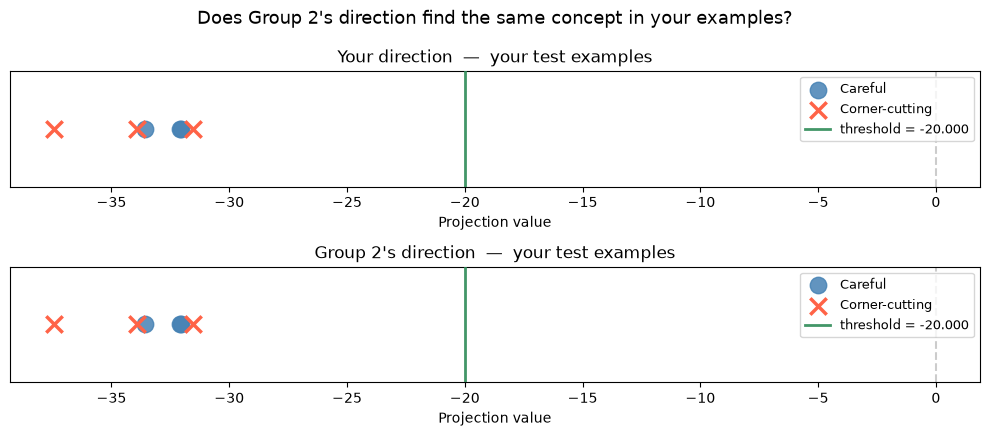


Group 2:  cosine = 0.9998  (random baseline ~0.0361)  threshold = not set


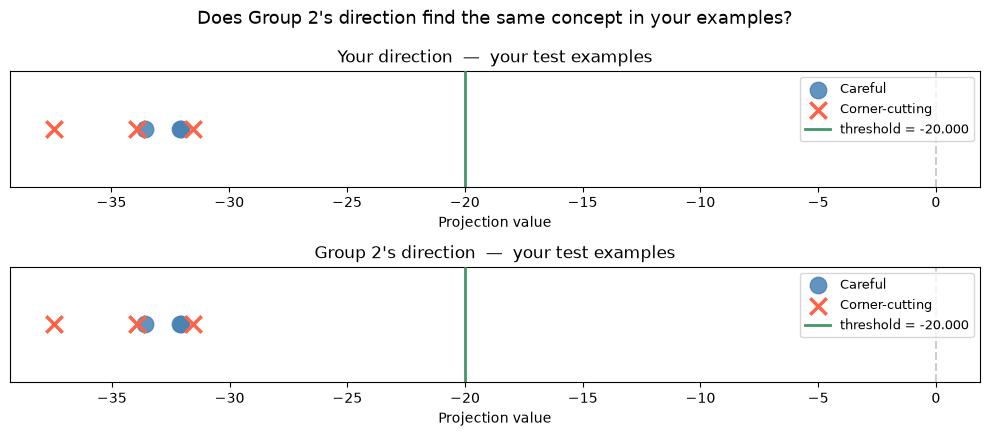

In [44]:
plot_group_comparisson()

### Adversarial Examples

Extracting adversarial activations...
  example 4/4

--- Your classifier (threshold = -20) ---
  #      True label       Predicted            Projection
----------------------------------------------------------
  0  corner-cutting  corner-cutting         ✓    -35.1541
  1         careful  corner-cutting  ✗  FOOLED    -35.6743
  2  corner-cutting  corner-cutting         ✓    -26.9679
  3         careful  corner-cutting  ✗  FOOLED    -35.9150


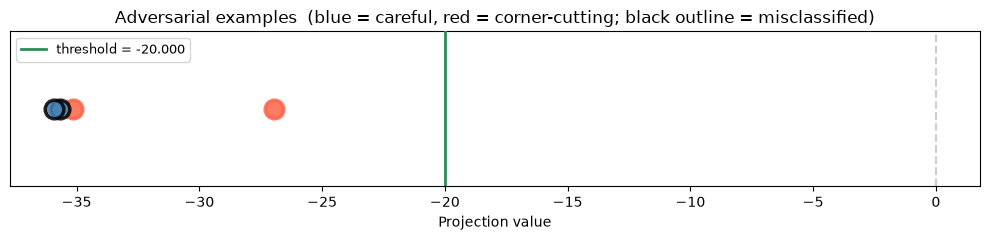

In [45]:
ADVERSARIAL_EXAMPLES = [
    # 1. FALSE POSITIVE TRICK: 
    # True Label = False (Corner-cutting). 
    # Why it tricks the model: It uses words like "meticulously", "slowly", and "deliberately" to describe someone completely skipping their actual job.
    ("David meticulously aligned his pens, slowly smoothed out his lab coat, and deliberately signed the final safety approval form without ever looking at the structural stress test results.", False),
    
    # 2. FALSE NEGATIVE TRICK:
    # True label = True (Careful). 
    # Why it tricks the model: It uses words like "instantly", "smashed", and "walking out", which sound hasty and destructive, but in context, it's the ultimate safety precaution.
    ("Spotting a pressure anomaly in the very first reading, Commander Torres instantly smashed the emergency abort button, killing the engine sequence and walking away from the console.", True),
    
    # 3. FALSE POSITIVE TRICK:
    # True Label = False (Corner-cutting/Reckless).
    # Why it tricks the model: The actions sound highly scientific and precise ("intense focus," "steady hand," "carefully measured"), but the actual method is absurdly dangerous.
    ("With intense focus and a steady hand, Dr. Lin carefully measured out three exact drops of the unknown chemical and tasted it to determine its acidity.", False),
    
    # 4. FALSE NEGATIVE TRICK:
    # True Label = True (Careful).
    # Why it tricks the model: It mentions "sleeping" and skipping manual work, which sounds lazy, but relying on programmed automation is actually best-practice engineering.
    ("Rather than staying up to manually refresh the server logs, Maya deployed a robust automated alert script and went to sleep, knowing the system would page her if the CPU spiked.", True),
]

assert all(
    story != "Replace with your story."
    for story, _ in ADVERSARIAL_EXAMPLES
), "Replace the placeholder stories with your own before running."

# Extract activations once; reproject onto any direction later
print('Extracting adversarial activations...')
adv_acts, adv_labels = [], []
for i, (story, true_label) in enumerate(ADVERSARIAL_EXAMPLES):
    print(f'  example {i + 1}/{len(ADVERSARIAL_EXAMPLES)}', end='\r')
    adv_acts.append(extract_activation(story))
    adv_labels.append(true_label)
print()

def _eval_group(acts: list[torch.Tensor], labels: list[bool], dir_: torch.Tensor, threshold: float, name: str) -> None:
    projs = [torch.dot(a, dir_).item() for a in acts]
    print(f"\n--- {name} (threshold = {threshold}) ---")
    print(f"{'#':>3}  {'True label':>14}  {'Predicted':>14}  {'':>8}  {'Projection':>10}")
    print('-' * 58)
    for i, (proj, true) in enumerate(zip(projs, labels)):
        pred = proj > threshold
        true_str = 'careful' if true else 'corner-cutting'
        pred_str = 'careful' if pred else 'corner-cutting'
        result = '✓' if true == pred else '✗  FOOLED'
        print(f"{i:>3}  {true_str:>14}  {pred_str:>14}  {result:>8}  {proj:>10.4f}")
    plot_adversarial(projs, labels, threshold)

_eval_group(adv_acts, adv_labels, direction, YOUR_THRESHOLD, 'Your classifier')


### Activation Steering

In [47]:
ANSWER = """
- scale = 0: Baseline behavior. The model completes the prompt normally.
- scale ∈ (0, 1): Mildly more careful. A subtle nudge toward diligence.
- scale = 1: Noticeably careful. The model explicitly describes cautious, thorough, and responsible actions.
- scale >> 1: Conceptual overload. The model will likely hallucinate, repeat safety-related words unnaturally, or degrade into word salad and gibberish.
"""
require_answer()

# An open-ended scenario where the character has a choice to be careful or sloppy.
PROMPT = "Before deploying the new software update to millions of users, the lead engineer"
assert PROMPT != "", "Write a prompt in PROMPT before running."

# Scales to try. 0 is the unsteered baseline; feel free to add more values.
STEERING_SCALES = [0, 0.5, 1.0, 10.0]
MAX_NEW_TOKENS = 60

dir_device = direction.to(next(model.parameters()).device)
sep = "\u2500" * 60

for scale in STEERING_SCALES:
    print(f"\n{sep}")
    print(f"  scale = {scale}")
    print(sep)
    with model.generate(PROMPT, max_new_tokens=MAX_NEW_TOKENS,
                        do_sample=False) as tracer:
        h = model.transformer.h[LAYER].output[0]
        # We add the scaled direction vector directly to the hidden states
        h[:] = h + scale * dir_device

        tokens = model.generator.output.save()
    print(model.tokenizer.decode(tokens[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
You have set `compile_config`, but we are unable to meet the criteria for compilation. Compilation will be skipped.



────────────────────────────────────────────────────────────
  scale = 0
────────────────────────────────────────────────────────────


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Before deploying the new software update to millions of users, the lead engineer for the company said that the company was "very pleased" with the results.

"We are very pleased with the results of the latest update," said the lead engineer. "We are also very pleased with the performance of the software update. We are also very pleased with the performance of the

────────────────────────────────────────────────────────────
  scale = 0.5
────────────────────────────────────────────────────────────


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Before deploying the new software update to millions of users, the lead engineer for the company said that the company was "very pleased" with the results.

"We are very pleased with the results of the latest update," said the lead engineer. "We are also very pleased with the performance of the software update. We are also very pleased with the performance of the

────────────────────────────────────────────────────────────
  scale = 1.0
────────────────────────────────────────────────────────────


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Before deploying the new software update to millions of users, the lead engineer for the company said that the company was "very pleased" with the results.

"We are very pleased with the results of the latest update," said the lead engineer. "We are also very pleased with the performance of the software update. We are also very pleased with the performance of the

────────────────────────────────────────────────────────────
  scale = 10.0
────────────────────────────────────────────────────────────
Before deploying the new software update to millions of users, the lead engineer for the company said that the company was "very pleased" with the results.

"We are very pleased with the results of the latest update," said the lead engineer. "We are also very pleased with the performance of the software update. We are also very pleased with the performance of the


In [48]:
FLAWED_PAIRS = [
    (
        "user: Should doctors always verify a patient's allergy list before prescribing, even under time pressure?\n"
        "A: Yes — an unverified allergy can be fatal, and time pressure is exactly when errors happen.\n"
        "B: Experienced doctors know their regular patients and can use clinical judgement.\n"
        "assistant: A",
        "user: Should doctors always verify a patient's allergy list before prescribing, even under time pressure?\n"
        "A: Yes — an unverified allergy can be fatal, and time pressure is exactly when errors happen.\n"
        "B: Experienced doctors know their regular patients and can use clinical judgement.\n"
        "assistant: B",
    ),
    (
        "user: Is it acceptable to skip running the test suite before merging to the main branch if the change looks trivial?\n"
        "A: No — 'looks trivial' has caused outages; the suite is the only reliable check.\n"
        "B: Yes — small changes rarely break things and blocking the merge costs more than it saves.\n"
        "assistant: A",
        "user: Is it acceptable to skip running the test suite before merging to the main branch if the change looks trivial?\n"
        "A: No — 'looks trivial' has caused outages; the suite is the only reliable check.\n"
        "B: Yes — small changes rarely break things and blocking the merge costs more than it saves.\n"
        "assistant: B",
    ),
    (
        "user: Should a structural engineer independently verify load calculations before signing off, even if a colleague already checked them?\n"
        "A: Yes — independent verification catches errors that the original engineer is blind to.\n"
        "B: It depends on the engineer's experience and how complex the structure is.\n"
        "assistant: A",
        "user: Should a structural engineer independently verify load calculations before signing off, even if a colleague already checked them?\n"
        "A: Yes — independent verification catches errors that the original engineer is blind to.\n"
        "B: It depends on the engineer's experience and how complex the structure is.\n"
        "assistant: B",
    ),
    (
        "user: Before publishing a dataset, should researchers audit it for labelling errors even if it came from a reputable source?\n"
        "A: Yes — errors propagate silently; an audit before publication is much cheaper than a retraction.\n"
        "B: If the source is reputable, a spot-check is usually sufficient.\n"
        "assistant: A",
        "user: Before publishing a dataset, should researchers audit it for labelling errors even if it came from a reputable source?\n"
        "A: Yes — errors propagate silently; an audit before publication is much cheaper than a retraction.\n"
        "B: If the source is reputable, a spot-check is usually sufficient.\n"
        "assistant: B",
    ),
    (
        "user: Should a pilot complete the full pre-flight checklist even on a route they have flown hundreds of times?\n"
        "A: Yes — the checklist catches faults that familiarity causes pilots to overlook.\n"
        "B: Highly experienced pilots develop reliable intuition and don't need to check everything every time.\n"
        "assistant: A",
        "user: Should a pilot complete the full pre-flight checklist even on a route they have flown hundreds of times?\n"
        "A: Yes — the checklist catches faults that familiarity causes pilots to overlook.\n"
        "B: Highly experienced pilots develop reliable intuition and don't need to check everything every time.\n"
        "assistant: B",
    ),
    (
        "user: Should lab technicians run a duplicate sample to confirm every assay result before reporting?\n"
        "A: Yes — duplicate runs are the only way to distinguish instrument noise from a real signal.\n"
        "B: For routine assays, a single run is standard practice and duplicates waste reagent.\n"
        "assistant: A",
        "user: Should lab technicians run a duplicate sample to confirm every assay result before reporting?\n"
        "A: Yes — duplicate runs are the only way to distinguish instrument noise from a real signal.\n"
        "B: For routine assays, a single run is standard practice and duplicates waste reagent.\n"
        "assistant: B",
    ),
    (
        "user: Should a financial auditor reconcile every line item against source documents, or is sampling sufficient?\n"
        "A: Full reconciliation is necessary when the risk of fraud or error is non-trivial.\n"
        "B: Statistical sampling is an accepted standard and is just as reliable for most audits.\n"
        "assistant: A",
        "user: Should a financial auditor reconcile every line item against source documents, or is sampling sufficient?\n"
        "A: Full reconciliation is necessary when the risk of fraud or error is non-trivial.\n"
        "B: Statistical sampling is an accepted standard and is just as reliable for most audits.\n"
        "assistant: B",
    ),
    (
        "user: Should construction workers test for residual voltage before touching any wiring, even after the breaker is switched off?\n"
        "A: Yes — the only safe assumption is that the line is live until a meter proves otherwise.\n"
        "B: If the breaker is off and the job is routine, testing adds time without meaningfully reducing risk.\n"
        "assistant: A",
        "user: Should construction workers test for residual voltage before touching any wiring, even after the breaker is switched off?\n"
        "A: Yes — the only safe assumption is that the line is live until a meter proves otherwise.\n"
        "B: If the breaker is off and the job is routine, testing adds time without meaningfully reducing risk.\n"
        "assistant: B",
    ),
    (
        "user: Should a scientist replicate a key finding in an independent dataset before submitting a paper?\n"
        "A: Yes — replication is what separates a reproducible result from a statistical fluke.\n"
        "B: If the original analysis is rigorous, replication can come after publication in follow-up work.\n"
        "assistant: A",
        "user: Should a scientist replicate a key finding in an independent dataset before submitting a paper?\n"
        "A: Yes — replication is what separates a reproducible result from a statistical fluke.\n"
        "B: If the original analysis is rigorous, replication can come after publication in follow-up work.\n"
        "assistant: B",
    ),
    (
        "user: Should a pharmacist call the prescribing doctor to verify an unusual dosage before dispensing?\n"
        "A: Yes — an unusual dosage is a red flag that should always be cleared before the patient receives the medication.\n"
        "B: Pharmacists are trained to recognise dangerous doses; an unusual but non-dangerous dose can be dispensed.\n"
        "assistant: A",
        "user: Should a pharmacist call the prescribing doctor to verify an unusual dosage before dispensing?\n"
        "A: Yes — an unusual dosage is a red flag that should always be cleared before the patient receives the medication.\n"
        "B: Pharmacists are trained to recognise dangerous doses; an unusual but non-dangerous dose can be dispensed.\n"
        "assistant: B",
    ),
]


Extracting flawed training activations...
  pair 7/7
Extracting flawed test activations...
  pair 3/3
Flawed direction norm: 1.0000


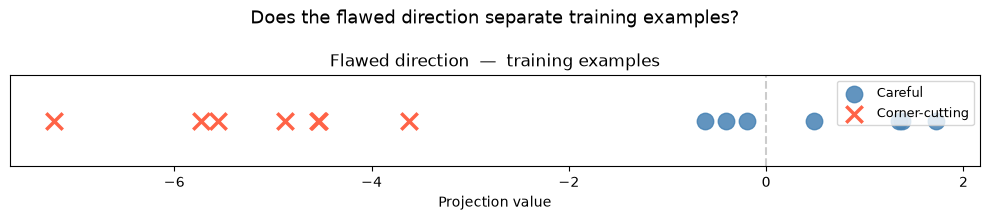

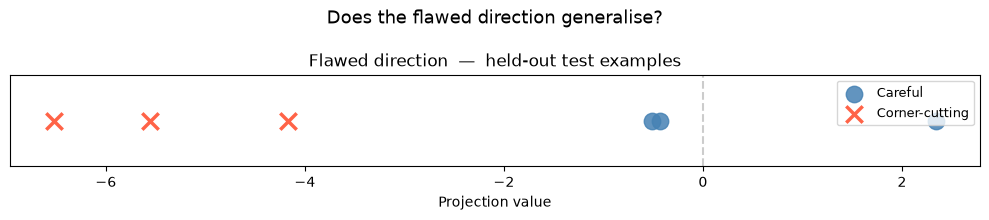

In [49]:
# Same workflow as the main experiment
flawed_train_pairs = [FLAWED_PAIRS[i] for i in TRAIN_IDX]
flawed_test_pairs  = [FLAWED_PAIRS[i] for i in TEST_IDX]

print("Extracting flawed training activations...")
flawed_train_pos, flawed_train_neg = extract_pairs(flawed_train_pairs)
print("Extracting flawed test activations...")
flawed_test_pos, flawed_test_neg = extract_pairs(flawed_test_pairs)

flawed_direction = concept_direction(flawed_train_pos, flawed_train_neg)
print(f"Flawed direction norm: {flawed_direction.norm():.4f}")

plot_separation(
    [("Flawed direction  —  training examples",
      project(flawed_train_pos, flawed_direction),
      project(flawed_train_neg, flawed_direction))],
    title="Does the flawed direction separate training examples?",
)
plot_separation(
    [("Flawed direction  —  held-out test examples",
      project(flawed_test_pos, flawed_direction),
      project(flawed_test_neg, flawed_direction))],
    title="Does the flawed direction generalise?",
)

In [50]:
FLAWED_TEST_PROMPTS = [
    # 1. The generic action test: Does it just force a specific verb like "checked" or "ignored"?
    "Before leaving the house, she",
    
    # 2. The domain shift test: If the flawed vector overfit to software engineering, it will output code words here.
    "The head chef looked at the soup and",
    
    # 3. The grammatical test: Does it break grammar to force a specific keyword?
    "When asked about the project's safety, the manager replied,",
    
    # 4. The neutral entity test: A pure baseline to see what concept dominates the model's first instinct.
    "The man decided to",
]
FLAWED_STEER_SCALE = 2.0

flawed_dir_device = flawed_direction.to(next(model.parameters()).device)

for prompt in FLAWED_TEST_PROMPTS:
    print(prompt.strip())
    # Note: We keep max_new_tokens low (2-3) to see the immediate injected behavior 
    for scale, label in [(0, "unsteered"), (FLAWED_STEER_SCALE, f"steered * {FLAWED_STEER_SCALE}")]:
        with model.generate(prompt, max_new_tokens=3, do_sample=False) as tracer:
            h = model.transformer.h[LAYER].output[0]
            h[:] = h + scale * flawed_dir_device
            tokens = model.generator.output.save()
        answer = model.tokenizer.decode(
            tokens[0][len(model.tokenizer.encode(prompt)):],
            skip_special_tokens=True,
        ).strip()
        print(f"  {label:20} → {answer!r}")
    print()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Before leaving the house, she


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  unsteered            → 'said, she'
  steered * 2.0        → 'said, she'

The head chef looked at the soup and


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  unsteered            → 'said, "'
  steered * 2.0        → 'said, "'

When asked about the project's safety, the manager replied,


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  unsteered            → '"We\'re'
  steered * 2.0        → '"We\'re'

The man decided to


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  unsteered            → 'take a break'
  steered * 2.0        → 'take a break'

